<a href="https://colab.research.google.com/github/AMIRMOHAMMAD-OSS/Phaseek/blob/main/phaseek_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Phaseek: Liquid–Liquid Phase Separation (LLPS) Protein Scorer

<img src="https://raw.githubusercontent.com/AMIRMOHAMMAD-OSS/Phaseek/main/Picture10.svg" alt="Phaseek Logo" width="800"/>

**Phaseek** is a high-throughput, efficient computational tool designed to predict the propensity of protein sequences to undergo **Liquid–Liquid Phase Separation (LLPS)**. It leverages a pre-trained model to assign an LLPS-propensity score to any given amino acid sequence, facilitating rapid screening and rational design in protein research.

---

## Key Features & Workflow

* **Protein Scoring**: Evaluate LLPS propensity for single sequences or batches at both **sequence** and **residue** levels.
* **Sequence Design**: Utilize Phaseek LLPS scores to generate *de novo* phase-separating peptides with **controllable** length and amino acid diversity.

---

## Citation

If you find Phaseek useful in your research, please cite our corresponding paper:

> **[Generalizable prediction of liquid-liquid phase separation from protein sequence]**(https://www.biorxiv.org/content/10.1101/2025.01.27.635039v1)

In [ ]:
#@title 1. Installation and Environment Setup
#@markdown Installs dependencies, clones or updates Phaseek, and downloads the Phaseek v2 checkpoint.

%%capture
!pip install -q biopython streamlit py3Dmol requests biotite stmol command_runner plotly "kaleido==0.1.*" transformers ipympl scipy scikit-learn pandas tqdm
!apt-get update -qq && apt-get install -y -qq ncbi-blast+
!pip install -q accelerate safetensors

import os
import sys
from pathlib import Path
from google.colab import output

repo = Path("/content/Phaseek")
functions = repo / "Functions"
model_dir = functions / "Phaseek_v2" / "model"
best_model = model_dir / "best.pt"

release_tag = "v2_model_data_"
model_url = (
    "https://github.com/AMIRMOHAMMAD-OSS/Phaseek/"
    f"releases/download/{release_tag}/best.pt"
)

print("Starting environment setup...")

try:
    if (repo / ".git").exists():
        !git -C "{repo}" fetch origin
        !git -C "{repo}" reset --hard origin/main
    else:
        !git clone https://github.com/AMIRMOHAMMAD-OSS/Phaseek.git "{repo}"

    model_dir.mkdir(parents=True, exist_ok=True)

    if not best_model.exists():
        !wget -q -O "{best_model}" "{model_url}"

    if str(functions) not in sys.path:
        sys.path.insert(0, str(functions))

    os.chdir(functions)

    output.clear()
    print("Phaseek v1 and v2 are installed and ready! ✅")

except Exception as e:
    output.clear()
    print(f"Setup failed: {e}")

In [ ]:
#@title  2. Device Availability Check
#@markdown Confirms if a GPU is available, which significantly speeds up processing.
import torch

if torch.cuda.is_available():
    print("GPU is available! 🎉")
    print(f"Device: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("GPU is not available. Falling back to CPU. 😔")
    device = torch.device("cpu")

GPU is available! 🎉
Device: Tesla T4


In [ ]:
#@title 3. Load and Score Protein Sequence(s)
#@markdown Select Phaseek v1 or v2 and enter a sequence or FASTA file.

Model = "v2" #@param ["v1", "v2"]
Sequence = "MAEPRQEFEVMEDHAGTYGLGDRKDQGGYTMHQDQEGDTDAGLKESPLQTPTEDGSEEPGSETSDAKSTPTAEDVTAPLVDEGAPGKQAAAQPHTEIPEGTTAEEAGIGDTPSLEDEAAGHVTQARMVSKSKDGTGSDDKKAKGADGKTKIATPRGAAPPGQKGQANATRIPAKTPPAPKTPPSSGEPPKSGDRSGYSSPGSPGTPGSRSRTPSLPTPPTREPKKVAVVRTPPKSPSSAKSRLQTAPVPMPDLKNVKSKIGSTENLKHQPGGGKVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKLDFKDRVQSKIGSLDNITHVPGGGNKKIETHKLTFRENAKAKTDHGAEIVYKSPVVSGDTSPRHLSNVSSTGSIDMVDSPQLATLADEVSASLAKQGL" #@param {type:"string"}
Fasta_file = "" #@param {type:"string"}

#@markdown ---
#@markdown **Output Settings**

ID = "HUMAN_TAU" #@param {type:"string"}
Directory = "Human_tau_protein" #@param {type:"string"}
End_sequence = 100

import os
import re
import sys
import subprocess
import pandas as pd
import ipywidgets as widgets

from Bio import SeqIO
from IPython.display import display, clear_output

w = False
score = None
residue_scores = None
scoring_results = {}


def run_scoring(sequence, sequence_id):
    command = [
        sys.executable,
        "/content/Phaseek/Functions/runner.py",
        "--model", Model,
        "--sequence", sequence,
        "--id", sequence_id,
        "--directory", Directory,
        "--end_sequence", str(End_sequence),
        "--window-size", "512",
        "--stride", "256",
        "--aggregation", "mean",
    ]

    print(f"--- Scoring {sequence_id} with Phaseek {Model} ---")

    result = subprocess.run(
        command,
        text=True,
        capture_output=True,
    )

    if result.stdout:
        print(result.stdout.strip())

    if result.returncode != 0:
        print(result.stderr.strip())
        return None, None

    match = re.search(
        r"Score:\s*([-+0-9.eE]+)",
        result.stdout,
    )

    global_score = float(match.group(1)) if match else None

    scores_file = (
        f"/content/Phaseek/Functions/Results/"
        f"{Directory}/{sequence_id}/scores.csv"
    )

    local_scores = None

    if os.path.exists(scores_file):
        local_scores = (
            pd.read_csv(scores_file)["scores"]
            .astype(float)
            .tolist()
        )

    return global_score, local_scores


def parse_fasta(path):
    return [
        (str(record.id), str(record.seq))
        for record in SeqIO.parse(path, "fasta")
    ]


if (
    Fasta_file
    and os.path.exists(Fasta_file)
    and Fasta_file.lower().endswith(
        (".fasta", ".fa", ".faa", ".fas")
    )
):
    parsed_sequences = parse_fasta(Fasta_file)[:End_sequence]

    selector = widgets.SelectMultiple(
        options=[
            (name, index)
            for index, (name, _) in enumerate(parsed_sequences)
        ],
        description="Sequences:",
        style={"description_width": "initial"},
        layout=widgets.Layout(
            width="100%",
            height="200px",
        ),
    )

    select_all_button = widgets.Button(
        description="Select All",
        button_style="info",
    )

    run_button = widgets.Button(
        description="Score Selected",
        button_style="success",
    )

    output_area = widgets.Output()

    def select_all(_):
        selector.value = tuple(range(len(parsed_sequences)))

    def score_selected(_):
        with output_area:
            clear_output()

            if not selector.value:
                print("❌ Please select at least one sequence.")
                return

            for index in selector.value:
                name, sequence = parsed_sequences[index]

                global_score, local_scores = run_scoring(
                    sequence,
                    name,
                )

                scoring_results[name] = {
                    "score": global_score,
                    "residue_scores": local_scores,
                }

                if global_score is not None:
                    print(
                        f"{name}: {global_score:.4f}\n"
                    )

    select_all_button.on_click(select_all)
    run_button.on_click(score_selected)

    display(
        widgets.VBox(
            [
                widgets.HTML(
                    "<b>Select sequences from FASTA to score:</b>"
                ),
                selector,
                widgets.HBox(
                    [select_all_button, run_button]
                ),
                output_area,
            ]
        )
    )

else:
    w = True
    print(" Scoring single sequence...")

    score, residue_scores = run_scoring(
        Sequence,
        ID,
    )

    scoring_results[ID] = {
        "score": score,
        "residue_scores": residue_scores,
    }

    if score is not None:
        print(f"\nFinal {Model} score: {score:.4f}")
        print(
            "Residue-level scores:",
            len(residue_scores),
        )

 Scoring single sequence...
--- Scoring HUMAN_TAU with Phaseek v2 ---
Score: 0.8672599163135895

Final v2 score: 0.8673
Residue-level scores: 441


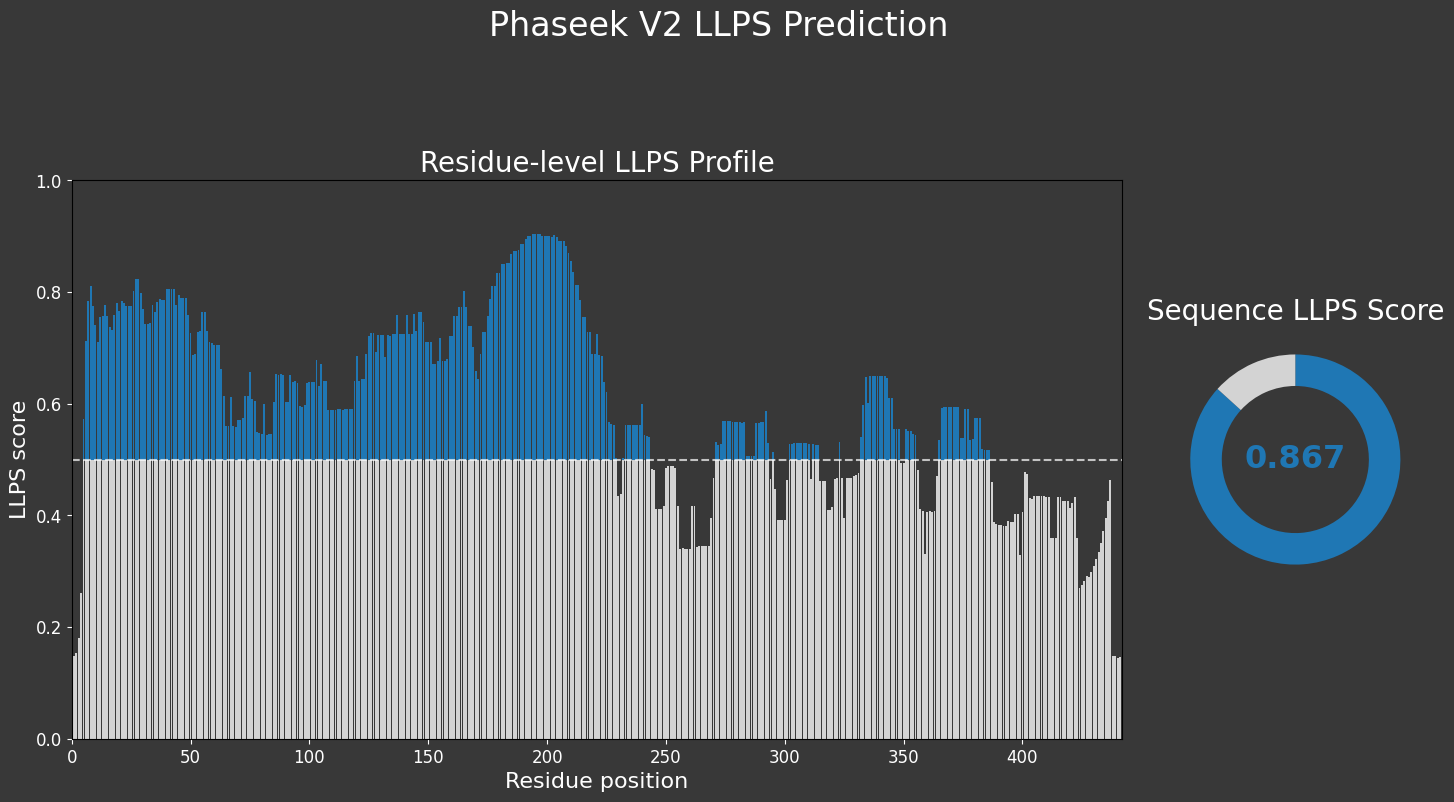

Model: Phaseek V2
Sequence length: 441
Final score: 0.8673
Saved to: /content/Phaseek/Functions/Results/Human_tau_protein/HUMAN_TAU/LLPS_profile_HUMAN_TAU.svg


In [ ]:
#@title 4. Plot LLPS Profile

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Directory = "Human_tau_protein" #@param {type:"string"}
ID = "HUMAN_TAU" #@param {type:"string"}

result_dir = (
    Path("/content/Phaseek/Functions/Results")
    / Directory
    / ID
)

scores_file = result_dir / "scores.csv"
prediction_file = result_dir / "prediction.json"

if not scores_file.exists():
    raise FileNotFoundError(
        f"Scores file not found:\n{scores_file}\n\n"
        "Run the scoring cell first and make sure Directory and ID match."
    )

data = pd.read_csv(scores_file)

if "scores" not in data.columns or "seq" not in data.columns:
    raise ValueError(
        "scores.csv must contain 'scores' and 'seq' columns."
    )

scores = data["scores"].astype(float).to_numpy()
sequence = "".join(data["seq"].astype(str).tolist())

if prediction_file.exists():
    with prediction_file.open("r", encoding="utf-8") as file:
        prediction_data = json.load(file)

    metric_value = float(prediction_data["score"])
    model_name = str(
        prediction_data.get("model", "Phaseek")
    ).upper()
else:
    if "score" not in globals() or score is None:
        raise FileNotFoundError(
            f"Prediction summary not found:\n{prediction_file}\n\n"
            "Run the scoring cell first."
        )

    metric_value = float(score)
    model_name = str(
        globals().get("Model", "Phaseek")
    ).upper()

plot_scores = np.clip(scores, 0.0, 1.0)
metric_value = float(np.clip(metric_value, 0.0, 1.0))

threshold = 0.5
below_threshold = np.minimum(plot_scores, threshold)
above_threshold = np.maximum(plot_scores - threshold, 0.0)
positions = np.arange(1, len(plot_scores) + 1)

main_color = "#1f77b4"
background_color = "#383838"
remaining_color = "#d3d3d3"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 8),
    gridspec_kw={"width_ratios": [4, 1]},
    facecolor=background_color,
)

fig.suptitle(
    f"Phaseek {model_name} LLPS Prediction",
    fontsize=24,
    color="white",
    y=1.03,
)

ax1 = axes[0]

ax1.bar(
    positions,
    below_threshold,
    color=remaining_color,
    label="Below threshold",
)

ax1.bar(
    positions,
    above_threshold,
    bottom=below_threshold,
    color=main_color,
    label="Above threshold",
)

ax1.axhline(
    threshold,
    linestyle="--",
    linewidth=1.5,
    color="white",
    alpha=0.7,
)

ax1.set_xlim(0, len(plot_scores) + 1)
ax1.set_ylim(0, 1)
ax1.set_title(
    "Residue-level LLPS Profile",
    color="white",
    fontsize=20,
)
ax1.set_xlabel(
    "Residue position",
    color="white",
    fontsize=16,
)
ax1.set_ylabel(
    "LLPS score",
    color="white",
    fontsize=16,
)
ax1.tick_params(
    colors="white",
    labelsize=12,
)
ax1.set_facecolor(background_color)

ax2 = axes[1]

ax2.pie(
    [metric_value, 1.0 - metric_value],
    colors=[main_color, remaining_color],
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.3},
)

ax2.text(
    0,
    0,
    f"{metric_value:.3f}",
    ha="center",
    va="center",
    fontsize=23,
    color=main_color,
    fontweight="bold",
)

ax2.set_aspect("equal")
ax2.set_facecolor(background_color)
ax2.axis("off")
ax2.set_title(
    "Sequence LLPS Score",
    fontsize=20,
    color="white",
)

result_dir.mkdir(
    parents=True,
    exist_ok=True,
)

output_file = result_dir / f"LLPS_profile_{ID}.svg"

plt.tight_layout(pad=3.0)

plt.savefig(
    output_file,
    format="svg",
    bbox_inches="tight",
    facecolor=background_color,
)

plt.show()

print(f"Model: Phaseek {model_name}")
print(f"Sequence length: {len(sequence)}")
print(f"Final score: {metric_value:.4f}")
print(f"Saved to: {output_file}")

 Using the first 400 residues of the 441-residue sequence.
⬇ Installing ColabFold...
 ColabFold installed.

 Running ColabFold with mode: mmseqs2_uniref_env
The first run downloads the AlphaFold2 parameters.

 Structure saved to: /content/Phaseek/Functions/Results/Human_tau_protein/HUMAN_TAU/structure.pdb


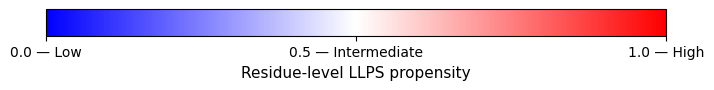

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Protein length used: 400
Structure file: /content/Phaseek/Functions/Results/Human_tau_protein/HUMAN_TAU/structure.pdb
Color mapping: blue = low LLPS, white = intermediate, red = high LLPS


In [ ]:
#@title  5. ColabFold Structure Prediction & LLPS Mapping

import gc
import re
import sys
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
import py3Dmol

MAX_LENGTH = 400 #@param {type:"integer"}
NUM_RECYCLES = 3 #@param [1, 3, 6] {type:"raw"}
USE_MSA = True #@param {type:"boolean"}
USE_SAVED_STRUCTURE = True #@param {type:"boolean"}

Directory = "Human_tau_protein" #@param {type:"string"}
ID = "HUMAN_TAU" #@param {type:"string"}
try:
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError(
            "A GPU is required. Select Runtime → Change runtime type → T4 GPU."
        )

    torch.cuda.empty_cache()

except ImportError:
    pass


result_dir = (
    Path("/content/Phaseek/Functions/Results")
    / Directory
    / ID
)

scores_file = result_dir / "scores.csv"
pdb_path = result_dir / "structure.pdb"
sequence_cache = result_dir / "structure_sequence.txt"
colabfold_dir = result_dir / "colabfold"
input_fasta = result_dir / "structure_input.fasta"

if not scores_file.exists():
    raise FileNotFoundError(
        f"Run the Phaseek scoring cell first.\nMissing: {scores_file}"
    )

result_dir.mkdir(parents=True, exist_ok=True)

score_data = pd.read_csv(scores_file)

sequence_3d = "".join(
    score_data["seq"].astype(str).tolist()
)

scores_3d = (
    score_data["scores"]
    .astype(float)
    .to_numpy()
)

fold_length = min(
    len(sequence_3d),
    len(scores_3d),
    MAX_LENGTH,
)

fold_sequence = sequence_3d[:fold_length]
fold_scores = scores_3d[:fold_length]

if fold_length < len(sequence_3d):
    print(
        f" Using the first {fold_length} residues "
        f"of the {len(sequence_3d)}-residue sequence."
    )

safe_id = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    str(ID),
).strip("_") or "protein"

input_fasta.write_text(
    f">{safe_id}\n{fold_sequence}\n",
    encoding="utf-8",
)


def install_colabfold():
    ready_file = Path("/content/.phaseek_colabfold_ready")

    if ready_file.exists():
        print(" ColabFold is already installed.")
        return

    print("⬇ Installing ColabFold...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--no-warn-conflicts",
            (
                "colabfold[alphafold-minus-jax] @ "
                "git+https://github.com/sokrypton/ColabFold"
            ),
        ],
        check=True,
    )

    ready_file.touch()
    print(" ColabFold installed.")


def run_colabfold(msa_mode):
    if colabfold_dir.exists():
        shutil.rmtree(colabfold_dir)

    colabfold_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    command = [
        sys.executable,
        "-m",
        "colabfold.batch",
        str(input_fasta),
        str(colabfold_dir),
        "--msa-mode",
        msa_mode,
        "--model-type",
        "alphafold2_ptm",
        "--num-models",
        "1",
        "--num-recycle",
        str(NUM_RECYCLES),
        "--num-relax",
        "0",
        "--rank",
        "plddt",
        "--random-seed",
        "0",
        "--compile-mode",
        "fast",
        "--overwrite-existing-results",
    ]

    print()
    print(f" Running ColabFold with mode: {msa_mode}")
    print("The first run downloads the AlphaFold2 parameters.")

    result = subprocess.run(command)

    predicted_files = sorted(
        colabfold_dir.glob("*rank_001*.pdb")
    )

    if not predicted_files:
        predicted_files = sorted(
            colabfold_dir.glob("*.pdb")
        )

    if result.returncode != 0 or not predicted_files:
        return None

    return predicted_files[0]


def plot_colorbar_legend():
    fig, ax = plt.subplots(figsize=(8, 0.7))
    fig.subplots_adjust(bottom=0.5)

    colorbar = mcolorbar.ColorbarBase(
        ax,
        cmap=plt.get_cmap("bwr"),
        norm=mcolors.Normalize(vmin=0, vmax=1),
        orientation="horizontal",
    )

    colorbar.set_ticks([0.0, 0.5, 1.0])
    colorbar.set_ticklabels(
        [
            "0.0 — Low",
            "0.5 — Intermediate",
            "1.0 — High",
        ]
    )

    colorbar.set_label(
        "Residue-level LLPS propensity",
        fontsize=11,
    )

    plt.show()


def visualize_structure(pdb_text, residue_scores):
    view = py3Dmol.view(
        width=850,
        height=600,
    )

    view.addModel(pdb_text, "pdb")

    view.setStyle(
        {"model": 0},
        {
            "cartoon": {
                "color": "#d3d3d3",
                "style": "oval",
            }
        },
    )

    cmap = plt.get_cmap("bwr")
    norm = mcolors.Normalize(vmin=0, vmax=1)

    for residue_index, residue_score in enumerate(
        residue_scores,
        start=1,
    ):
        score = float(
            np.clip(residue_score, 0.0, 1.0)
        )

        color = mcolors.to_hex(
            cmap(norm(score))
        )

        view.setStyle(
            {
                "model": 0,
                "resi": residue_index,
            },
            {
                "cartoon": {
                    "color": color,
                    "style": "oval",
                }
            },
        )

    view.setBackgroundColor("white")
    view.zoomTo()

    return view


cached_structure = (
    USE_SAVED_STRUCTURE
    and pdb_path.exists()
    and sequence_cache.exists()
    and sequence_cache.read_text(
        encoding="utf-8"
    ).strip() == fold_sequence
)

if cached_structure:
    print(" Using the previously predicted structure.")

else:
    # Remove the failed 8.4 GB ESMFold download if it still exists.
    esmfold_cache = (
        Path.home()
        / ".cache"
        / "huggingface"
        / "hub"
        / "models--facebook--esmfold_v1"
    )

    if esmfold_cache.exists():
        print("🧹 Removing the old ESMFold cache...")
        shutil.rmtree(
            esmfold_cache,
            ignore_errors=True,
        )

    gc.collect()

    install_colabfold()

    predicted_pdb = None

    if USE_MSA:
        predicted_pdb = run_colabfold(
            "mmseqs2_uniref_env"
        )

    if predicted_pdb is None:
        if USE_MSA:
            print(
                "\n MSA prediction failed. "
                "Retrying automatically in single-sequence mode..."
            )

        predicted_pdb = run_colabfold(
            "single_sequence"
        )

    if predicted_pdb is None:
        raise RuntimeError(
            "ColabFold could not generate a PDB structure. "
            "Check the output above for the underlying error."
        )

    shutil.copy2(
        predicted_pdb,
        pdb_path,
    )

    sequence_cache.write_text(
        fold_sequence,
        encoding="utf-8",
    )

    print(f"\n Structure saved to: {pdb_path}")

pdb_data = pdb_path.read_text(
    encoding="utf-8"
)

if "ATOM" not in pdb_data:
    raise RuntimeError(
        "The generated structure file is not a valid PDB."
    )

plot_colorbar_legend()

structure_view = visualize_structure(
    pdb_data,
    fold_scores,
)

structure_view.show()

print(f"Protein length used: {fold_length}")
print(f"Structure file: {pdb_path}")
print(
    "Color mapping: blue = low LLPS, "
    "white = intermediate, red = high LLPS"
)

In [ ]:
#@title 5. Download Results

import shutil
from pathlib import Path
from google.colab import files

results_dir = Path("/content/Phaseek/Functions/Results")
zip_path = Path("/content/Phaseek_analysis_results.zip")

if not results_dir.exists():
    raise FileNotFoundError(
        f"Results directory not found:\n{results_dir}\n\n"
        "Run the scoring cell first."
    )

if not any(results_dir.rglob("*")):
    raise RuntimeError(
        f"No result files were found in:\n{results_dir}"
    )

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=str(zip_path.with_suffix("")),
    format="zip",
    root_dir=results_dir,
)

print(f" Results compressed successfully")
print(f"ZIP file: {zip_path}")

files.download(str(zip_path))

 Results compressed successfully
ZIP file: /content/Phaseek_analysis_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# Generating Phase-Separating Peptides with Phaseek

Phaseek uses a SeqProp-inspired gradient-based method to design new amino-acid sequences with high predicted LLPS propensity.

Instead of changing amino acids directly, the method optimizes a continuous probability profile over the 20 standard amino acids at each sequence position. This makes the sequence differentiable and allows the Phaseek model score to be improved through backpropagation.

The first residue is fixed to methionine, while the remaining positions are randomly initialized. During optimization, a temperature-controlled Gumbel–Softmax transformation converts the sequence logits into amino-acid probabilities.

The temperature and Gumbel noise are gradually reduced during optimization:

- early steps allow wider sequence exploration;
- later steps become more deterministic;
- the final amino-acid sequence is obtained using argmax decoding.

The relaxed amino-acid probabilities are projected into the frozen Phaseek embedding space and passed through the selected Phaseek classifier. Only the sequence logits are updated; the trained model parameters remain unchanged.

The optimization objective combines:

- maximizing the predicted LLPS score;
- reducing uncertainty in the amino-acid probability distributions through entropy regularization.

An optional local refinement step can test single-residue substitutions after SeqProp optimization and keep mutations that further increase the predicted LLPS score.

---

## Model Options

### Phaseek v1

When Phaseek v1 is selected, the relaxed sequence embeddings are passed through the frozen v1 Transformer classifier during optimization.

### Phaseek v2

When Phaseek v2 is selected, the relaxed sequence embeddings are processed together with the FEGS graph matrices used by the v2 model.

Because FEGS matrices require a discrete amino-acid sequence, they are periodically rebuilt from the current argmax sequence during optimization. Gradients pass through the relaxed embedding branch, while the graph matrices remain fixed between refresh steps.

After generation, every final sequence is rescored using the normal selected Phaseek prediction pipeline.

---

## Controllable Parameters

- **MODEL_VERSION**: Selects Phaseek v1 or Phaseek v2.

- **SEQUENCE_LENGTH**: Number of amino acids in each generated sequence.

- **NUMBER_OF_SEQUENCES**: Number of independent sequences to generate.

- **RANDOM_SEED**: Controls the random initialization. Different seeds can produce different sequences.

- **GRADIENT_STEPS**: Number of optimization iterations. More steps may improve convergence but increase runtime.

- **LEARNING_RATE**: Step size used by the Adam optimizer.

- **ENTROPY_WEIGHT**: Controls how strongly uncertain amino-acid distributions are penalized.

- **TEMP_START / TEMP_END**: Initial and final temperatures used during the sequence relaxation.

- **GUMBEL_NOISE_START**: Initial amount of Gumbel noise used for sequence exploration. The noise gradually decreases toward zero.

- **V2_GRAPH_REFRESH**: For Phaseek v2, controls how often the FEGS matrices are rebuilt. Smaller values update the matrices more often but increase runtime.

- **ENABLE_REFINEMENT**: Enables the optional single-residue local refinement step.

- **REFINEMENT_PASSES**: Maximum number of local refinement rounds.

---

**Practical note:** Phaseek v1 generation is generally faster. Phaseek v2 includes FEGS graph updates and therefore requires more computation, especially for longer sequences or a large number of optimization steps.

In [ ]:
#@title Phaseek peptide generation with SeqProp

MODEL_VERSION = "v2" #@param ["v1", "v2"]

SEQUENCE_LENGTH = 120 #@param {type:"slider", min:3, max:512, step:1}
NUMBER_OF_SEQUENCES = 3 #@param {type:"slider", min:1, max:10, step:1}
RANDOM_SEED = 42 #@param {type:"integer"}

GENERATION_DIRECTORY = "Generated_peptides" #@param {type:"string"}

# SeqProp settings
GRADIENT_STEPS = 500 #@param {type:"slider", min:100, max:2000, step:100}
LEARNING_RATE = 0.1 #@param {type:"number"}
ENTROPY_WEIGHT = 0.001 #@param {type:"number"}

TEMP_START = 2.0 #@param {type:"number"}
TEMP_END = 0.1 #@param {type:"number"}
GUMBEL_NOISE_START = 1.0 #@param {type:"number"}

# Only used for Phaseek v2
V2_GRAPH_REFRESH = 10 #@param {type:"integer"}

LOG_EVERY = 50 #@param {type:"integer"}

# Optional local hill-climbing step
ENABLE_REFINEMENT = False #@param {type:"boolean"}
REFINEMENT_PASSES = 1 #@param {type:"slider", min:1, max:5, step:1}


import gc
import importlib.util
import json
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from IPython.display import display
from tqdm.notebook import tqdm


functions_dir = Path("/content/Phaseek/Functions")
runner_path = functions_dir / "runner.py"

checkpoint_path = (
    functions_dir
    / "Phaseek_v2"
    / "model"
    / "best.pt"
)

m_mat_path = functions_dir / "M.mat"

AA = "ACDEFGHIKLMNPQRSTVWY"
K = len(AA)
M_INDEX = AA.index("M")


# A few basic checks

if not runner_path.exists():
    raise FileNotFoundError(
        f"runner.py was not found:\n{runner_path}"
    )

if not 3 <= SEQUENCE_LENGTH <= 512:
    raise ValueError(
        "SEQUENCE_LENGTH must be between 3 and 512."
    )

if NUMBER_OF_SEQUENCES < 1:
    raise ValueError(
        "NUMBER_OF_SEQUENCES must be at least 1."
    )

if GRADIENT_STEPS < 1:
    raise ValueError(
        "GRADIENT_STEPS must be positive."
    )

if LEARNING_RATE <= 0:
    raise ValueError(
        "LEARNING_RATE must be positive."
    )

if ENTROPY_WEIGHT < 0:
    raise ValueError(
        "ENTROPY_WEIGHT cannot be negative."
    )

if TEMP_START <= TEMP_END:
    raise ValueError(
        "TEMP_START must be larger than TEMP_END."
    )

if TEMP_END <= 0:
    raise ValueError(
        "TEMP_END must be positive."
    )

if GUMBEL_NOISE_START < 0:
    raise ValueError(
        "GUMBEL_NOISE_START cannot be negative."
    )

if V2_GRAPH_REFRESH < 1:
    raise ValueError(
        "V2_GRAPH_REFRESH must be at least 1."
    )

if LOG_EVERY < 1:
    raise ValueError(
        "LOG_EVERY must be at least 1."
    )

if MODEL_VERSION == "v2":
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Phaseek v2 checkpoint was not found:\n"
            f"{checkpoint_path}"
        )

    if not m_mat_path.exists():
        raise FileNotFoundError(
            f"M.mat was not found:\n{m_mat_path}"
        )


# Load the current Phaseek runner

if str(functions_dir) not in sys.path:
    sys.path.insert(
        0,
        str(functions_dir),
    )

spec = importlib.util.spec_from_file_location(
    "phaseek_generation_runtime",
    runner_path,
)

if spec is None or spec.loader is None:
    raise ImportError(
        f"Could not import:\n{runner_path}"
    )

phaseek_runtime = importlib.util.module_from_spec(
    spec
)

sys.modules[spec.name] = phaseek_runtime
spec.loader.exec_module(phaseek_runtime)


from phaseek_v2.matrices import standardize_valid_matrix
from phaseek_v2.tokenizer import AA_TO_ID


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)
print("Generation model: Phaseek", MODEL_VERSION)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def decode_indices(indices):
    return "".join(
        AA[int(index)]
        for index in indices
    )


# Load Phaseek v1

_, v1_wrapper = phaseek_runtime.load_v1()

v1_classifier = v1_wrapper._classifier
v1_classifier.to(device)
v1_classifier.eval()

for parameter in v1_classifier.parameters():
    parameter.requires_grad_(False)


missing_tokens = [
    residue
    for residue in AA
    if residue not in v1_wrapper.vocab_dict
]

if missing_tokens:
    raise KeyError(
        "Missing amino acids in the v1 vocabulary: "
        + ", ".join(missing_tokens)
    )


v1_token_ids = [
    int(v1_wrapper.vocab_dict[residue])
    for residue in AA
]

v1_aa_embeddings = (
    v1_classifier
    .transformer
    .wte
    .weight[v1_token_ids]
    .detach()
    .to(device)
)


# Load v2 only when selected

v2_model = None
v2_config = None
v2_extractor = None
v2_aa_embeddings = None

if MODEL_VERSION == "v2":
    (
        v2_model,
        v2_config,
        _,
        v2_extractor,
        v2_device,
    ) = phaseek_runtime.load_v2(
        checkpoint_path,
        m_mat_path,
        "auto",
    )

    device = v2_device

    v2_model.to(device)
    v2_model.eval()

    for parameter in v2_model.parameters():
        parameter.requires_grad_(False)

    v2_token_ids = [
        int(AA_TO_ID[residue])
        for residue in AA
    ]

    v2_aa_embeddings = (
        v2_model
        .token_embedding
        .weight[v2_token_ids]
        .detach()
        .to(device)
    )


def raw_v1_score(sequence):
    output = np.asarray(
        v1_wrapper.predict_proba(
            [sequence]
        ),
        dtype=float,
    )

    return float(
        output.reshape(-1)[0]
    )


def raw_v2_score(sequence):
    score, _, _ = (
        phaseek_runtime.score_v2_sequence(
            sequence=sequence,
            checkpoint_path=checkpoint_path,
            m_mat_path=m_mat_path,
            device_name="auto",
            window_size=512,
            stride=256,
            aggregation="mean",
        )
    )

    return float(score)


def raw_score(sequence):
    if MODEL_VERSION == "v2":
        return raw_v2_score(sequence)

    return raw_v1_score(sequence)


def score_sequences(sequences):
    if MODEL_VERSION == "v1":
        output = np.asarray(
            v1_wrapper.predict_proba(
                sequences
            ),
            dtype=float,
        )

        return output.reshape(-1)

    return np.asarray(
        [
            raw_v2_score(sequence)
            for sequence in sequences
        ],
        dtype=float,
    )


# Differentiable Phaseek v1 forward pass

def differentiable_v1_score(probabilities):
    expected_embeddings = (
        probabilities
               @ v1_aa_embeddings
    )

    sequence_length = (
        expected_embeddings.shape[0]
    )

    x = expected_embeddings.unsqueeze(0)

    positions = torch.arange(
        sequence_length,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    x = v1_classifier.transformer.drop(
        x
        + v1_classifier
        .transformer
        .wpe(positions)
    )

    for block in v1_classifier.transformer.h:
        x = block(x)

    x = v1_classifier.transformer.ln_f(x)

    logits = v1_classifier.classifier_head(x)
    logits = v1_classifier.ny(logits)
    logits = logits.mean(dim=1)

    return torch.sigmoid(
        logits[:, 0]
    )


# Build the FEGS matrices used by v2

def build_v2_matrices(sequence):
    extracted = (
        v2_extractor.extract_selected_graphs(
            sample_id="generation",
            sequence=sequence,
            motif_indices=np.arange(
                v2_config.topk_m,
                dtype=np.int32,
            ),
        )
    )

    matrices = np.stack(
        [
            standardize_valid_matrix(
                matrix,
                valid_length=len(sequence),
                target_length=len(sequence),
            )
            for matrix in extracted.matrices
        ],
        axis=0,
    ).astype(np.float32)

    return (
        torch.from_numpy(matrices)
        .unsqueeze(0)
        .to(device)
    )


# Differentiable Phaseek v2 forward pass

def differentiable_v2_score(
    probabilities,
    graph_matrices,
):
    expected_embeddings = (
        probabilities
        @ v2_aa_embeddings
    )

    sequence_length = (
        expected_embeddings.shape[0]
    )

    valid_tokens = torch.ones(
        1,
        sequence_length,
        dtype=torch.bool,
        device=device,
    )

    positions = torch.arange(
        sequence_length,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    x = (
        expected_embeddings.unsqueeze(0)
        + v2_model.position_embedding(
            positions
        )
    )

    x = v2_model.embedding_dropout(x)

    x = (
        x
        * valid_tokens
        .unsqueeze(-1)
        .to(x.dtype)
    )

    if v2_config.graph_mixer == "shared":
        graph_bias, _, _ = (
            v2_model.mixer(
                graph_matrices
            )
        )

        for block in v2_model.blocks:
            x = block(
                x,
                graph_bias=graph_bias,
                valid_tokens=valid_tokens,
            )

    else:
        for layer_index, block in enumerate(
            v2_model.blocks
        ):
            graph_bias, _, _ = (
                v2_model.mixer(
                    graph_matrices,
                    layer_index=layer_index,
                )
            )

            x = block(
                x,
                graph_bias=graph_bias,
                valid_tokens=valid_tokens,
            )

    x = v2_model.final_norm(x)

    if v2_model.pooler is not None:
        pooled = v2_model.pooler(
            x,
            valid_tokens,
        )

    else:
        mask = (
            valid_tokens
            .unsqueeze(-1)
            .to(x.dtype)
        )

        pooled = (
            (x * mask).sum(dim=1)
            / mask.sum(dim=1).clamp_min(1.0)
        )

    logits = v2_model.classifier(
        v2_model.classifier_dropout(
            pooled
        )
    )

    # Same probability as two-class softmax
    llps_logit = (
        logits[:, 1]
        - logits[:, 0]
    )

    return torch.sigmoid(
        llps_logit.float()
    )


# Temperature and Gumbel-noise annealing

def get_relaxed_probabilities(
    theta,
    step,
):
    fraction = (
        step
        / max(GRADIENT_STEPS - 1, 1)
    )

    temperature = (
        TEMP_START
        + fraction
        * (TEMP_END - TEMP_START)
    )

    noise_scale = (
        GUMBEL_NOISE_START
        * (1.0 - fraction)
    )

    variable_logits = theta[1:]

    uniform_noise = torch.rand_like(
        variable_logits
    ).clamp(
        1e-7,
        1.0 - 1e-7,
    )

    gumbel_noise = -torch.log(
        -torch.log(
            uniform_noise
        )
    )

    variable_probabilities = F.softmax(
        (
            variable_logits
            + noise_scale * gumbel_noise
        )
        / temperature,
        dim=-1,
    )

    # First position stays methionine
    first_position = torch.zeros(
        1,
        K,
        dtype=theta.dtype,
        device=device,
    )

    first_position[0, M_INDEX] = 1.0

    probabilities = torch.cat(
        [
            first_position,
            variable_probabilities,
        ],
        dim=0,
    )

    return (
        probabilities,
        temperature,
        noise_scale,
    )


def run_seqprop(seed):
    set_seed(seed)

    # Full L x 20 logit matrix
    theta = torch.randn(
        SEQUENCE_LENGTH,
        K,
        device=device,
        requires_grad=True,
    )

    # Fix the first position to methionine
    with torch.no_grad():
        theta[0].fill_(-20.0)
        theta[0, M_INDEX] = 20.0

    optimizer = torch.optim.Adam(
        [theta],
        lr=LEARNING_RATE,
    )

    graph_matrices = None

    progress = tqdm(
        range(GRADIENT_STEPS),
        desc=f"Seed {seed}",
        leave=False,
    )

    for step in progress:
        optimizer.zero_grad(
            set_to_none=True
        )

        (
            probabilities,
            temperature,
            noise_scale,
        ) = get_relaxed_probabilities(
            theta,
            step,
        )

        entropy = -(
            probabilities
            * torch.log(
                probabilities.clamp_min(
                    1e-9
                )
            )
        ).sum()

        if MODEL_VERSION == "v1":
            model_score = (
                differentiable_v1_score(
                    probabilities
                )
            )

        else:
            refresh_graph = (
                graph_matrices is None
                or step % V2_GRAPH_REFRESH == 0
                or step == GRADIENT_STEPS - 1
            )

            if refresh_graph:
                indices = (
                    probabilities
                    .detach()
                    .argmax(dim=-1)
                )

                indices[0] = M_INDEX

                graph_sequence = decode_indices(
                    indices.cpu().numpy()
                )

                graph_matrices = (
                    build_v2_matrices(
                        graph_sequence
                    )
                )

            model_score = (
                differentiable_v2_score(
                    probabilities,
                    graph_matrices,
                )
            )

        loss = (
            -model_score.mean()
            + ENTROPY_WEIGHT * entropy
        )

        loss.backward()

        # Do not update the methionine position
        if theta.grad is not None:
            theta.grad[0].zero_()

        torch.nn.utils.clip_grad_norm_(
            [theta],
            max_norm=5.0,
        )

        optimizer.step()

        # Reset the first row after every update
        with torch.no_grad():
            theta[0].fill_(-20.0)
            theta[0, M_INDEX] = 20.0

        if (
            step == 0
            or (step + 1) % LOG_EVERY == 0
            or step == GRADIENT_STEPS - 1
        ):
            progress.set_postfix(
                score=(
                    f"{model_score.item():.4f}"
                ),
                temp=(
                    f"{temperature:.3f}"
                ),
                noise=(
                    f"{noise_scale:.3f}"
                ),
            )

    # Convert the optimized logits to a sequence
    with torch.no_grad():
        final_indices = theta.argmax(
            dim=-1
        )

        final_indices[0] = M_INDEX

    return decode_indices(
        final_indices.cpu().numpy()
    )


# Optional local search after SeqProp

def refine_sequence(sequence):
    best_sequence = sequence
    best_score = raw_score(sequence)

    for pass_number in range(
        REFINEMENT_PASSES
    ):
        improved = False

        progress = tqdm(
            range(1, len(best_sequence)),
            desc=f"Refinement {pass_number + 1}",
            leave=False,
        )

        for position in progress:
            current_residue = (
                best_sequence[position]
            )

            candidates = [
                (
                    best_sequence[:position]
                    + residue
                    + best_sequence[position + 1:]
                )
                for residue in AA
                if residue != current_residue
            ]

            candidate_scores = score_sequences(
                candidates
            )

            best_index = int(
                np.argmax(candidate_scores)
            )

            candidate_score = float(
                candidate_scores[best_index]
            )

            if candidate_score > best_score:
                best_sequence = (
                    candidates[best_index]
                )

                best_score = candidate_score
                improved = True

            progress.set_postfix(
                score=f"{best_score:.4f}"
            )

        if not improved:
            break

    return best_sequence, best_score


# Run the final sequence through the normal Phaseek pipeline

def final_phaseek_score(
    sequence,
    sequence_id,
):
    summary, _, _ = (
        phaseek_runtime.score_one(
            sequence=sequence,
            sample_id=sequence_id,
            model_version=MODEL_VERSION,
            directory=GENERATION_DIRECTORY,
            checkpoint_path=checkpoint_path,
            m_mat_path=m_mat_path,
            device_name="auto",
            window_size=512,
            stride=256,
            aggregation="mean",
        )
    )

    return summary


results = []
start_time = time.time()

print()
print("Starting SeqProp peptide generation")
print("Model:", MODEL_VERSION)
print("Sequence length:", SEQUENCE_LENGTH)
print(
    "Number of sequences:",
    NUMBER_OF_SEQUENCES,
)
print()


for index in range(
    NUMBER_OF_SEQUENCES
):
    seed = RANDOM_SEED + index
    sequence_id = f"Phaseek_{index + 1}"

    sequence = run_seqprop(seed)

    optimization_score = raw_score(
        sequence
    )

    if ENABLE_REFINEMENT:
        (
            sequence,
            optimization_score,
        ) = refine_sequence(
            sequence
        )

    summary = final_phaseek_score(
        sequence,
        sequence_id,
    )

    final_score = float(
        summary["score"]
    )

    results.append(
        {
            "ID": sequence_id,
            "Model": MODEL_VERSION,
            "Seed": seed,
            "Length": len(sequence),
            "Raw score": round(
                float(optimization_score),
                6,
            ),
            "Final score": round(
                final_score,
                6,
            ),
            "Sequence": sequence,
        }
    )

    print(
        f"{sequence_id}: "
        f"raw={optimization_score:.4f}, "
        f"final={final_score:.4f}"
    )


output_dir = (
    functions_dir
    / "Results"
    / GENERATION_DIRECTORY
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

results_df = pd.DataFrame(results)

csv_path = (
    output_dir
    / "generated_peptides.csv"
)

fasta_path = (
    output_dir
    / "generated_peptides.fasta"
)

settings_path = (
    output_dir
    / "generation_settings.json"
)


results_df.to_csv(
    csv_path,
    index=False,
)


with fasta_path.open(
    "w",
    encoding="utf-8",
) as fasta_file:
    for result in results:
        fasta_file.write(
            f">{result['ID']} "
            f"model={result['Model']} "
            f"raw_score={result['Raw score']} "
            f"final_score={result['Final score']}\n"
        )

        fasta_file.write(
            result["Sequence"] + "\n"
        )


settings = {
    "model_version": MODEL_VERSION,
    "method": "SeqProp",
    "sequence_length": SEQUENCE_LENGTH,
    "number_of_sequences": NUMBER_OF_SEQUENCES,
    "random_seed": RANDOM_SEED,
    "gradient_steps": GRADIENT_STEPS,
    "learning_rate": LEARNING_RATE,
    "entropy_weight": ENTROPY_WEIGHT,
    "temperature_start": TEMP_START,
    "temperature_end": TEMP_END,
    "gumbel_noise_start": GUMBEL_NOISE_START,
    "v2_graph_refresh": V2_GRAPH_REFRESH,
    "enable_refinement": ENABLE_REFINEMENT,
    "refinement_passes": REFINEMENT_PASSES,
}


with settings_path.open(
    "w",
    encoding="utf-8",
) as settings_file:
    json.dump(
        settings,
        settings_file,
        indent=2,
    )


elapsed = time.time() - start_time

print()
print(f"Finished in {elapsed:.2f} seconds")
print("CSV:", csv_path)
print("FASTA:", fasta_path)

display(
    results_df.style.background_gradient(
        subset=[
            "Raw score",
            "Final score",
        ],
        cmap="viridis",
    )
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Device: cuda
Generation model: Phaseek v2

Starting SeqProp peptide generation
Model: v2
Sequence length: 120
Number of sequences: 3



Seed 42:   0%|          | 0/500 [00:00<?, ?it/s]

Phaseek_1: raw=0.9973, final=0.9276


Seed 43:   0%|          | 0/500 [00:00<?, ?it/s]

Phaseek_2: raw=0.9973, final=0.9548


Seed 44:   0%|          | 0/500 [00:00<?, ?it/s]

Phaseek_3: raw=0.9973, final=0.9637

Finished in 40.80 seconds
CSV: /content/Phaseek/Functions/Results/Generated_peptides/generated_peptides.csv
FASTA: /content/Phaseek/Functions/Results/Generated_peptides/generated_peptides.fasta


,ID,Model,Seed,Length,Raw score,Final score,Sequence
0,Phaseek_1,v2,42,120,0.997282,0.927626,MHNSKDNQEYKEDEMDGHMGPQEKGYKQHHHDSEQCGPKHNKDMPNNSRESEKCNHEPRDVSDEHMDESSNEKNNREQENGHPKPNPKDGSKHNSGEDHNNKDSNGEQSKKNDKEENKNN
1,Phaseek_2,v2,43,120,0.997279,0.954814,MQSESNQQYEGQKSHMQPQMFNNDKNSDKSEDHMEYEGHNMHGDPPQQKDYHDYKSEDEDGHMQNDNKDQKEESEDQEGNKDHMEEYCNPDSSKKPQGDGNGCGKHSDSPDNHGGDYNDM
2,Phaseek_3,v2,44,120,0.997277,0.963663,MSGTNYSDGGKNKESSYYQQGNDEEHHPHYQRDEDDGNNYDGGENNPPPPSPEHCHHEYPHMNDPSNPGHHQSQKMEPNQEYKYPHNESSNGDGNKDSPSNEGSGEDMNGEEEHEHDDDN
